# Neural Operator

Solutions of PDEs are operators that act as mappings between function spaces. They take initial conditions, boundary conditions, and source terms as inputs and yield the PDE solution as output. For instance, in fluid dynamics, the solution operator can compute the flow profile at a specific future time (e.g. $T = 1$) given the initial flow and boundary conditions.



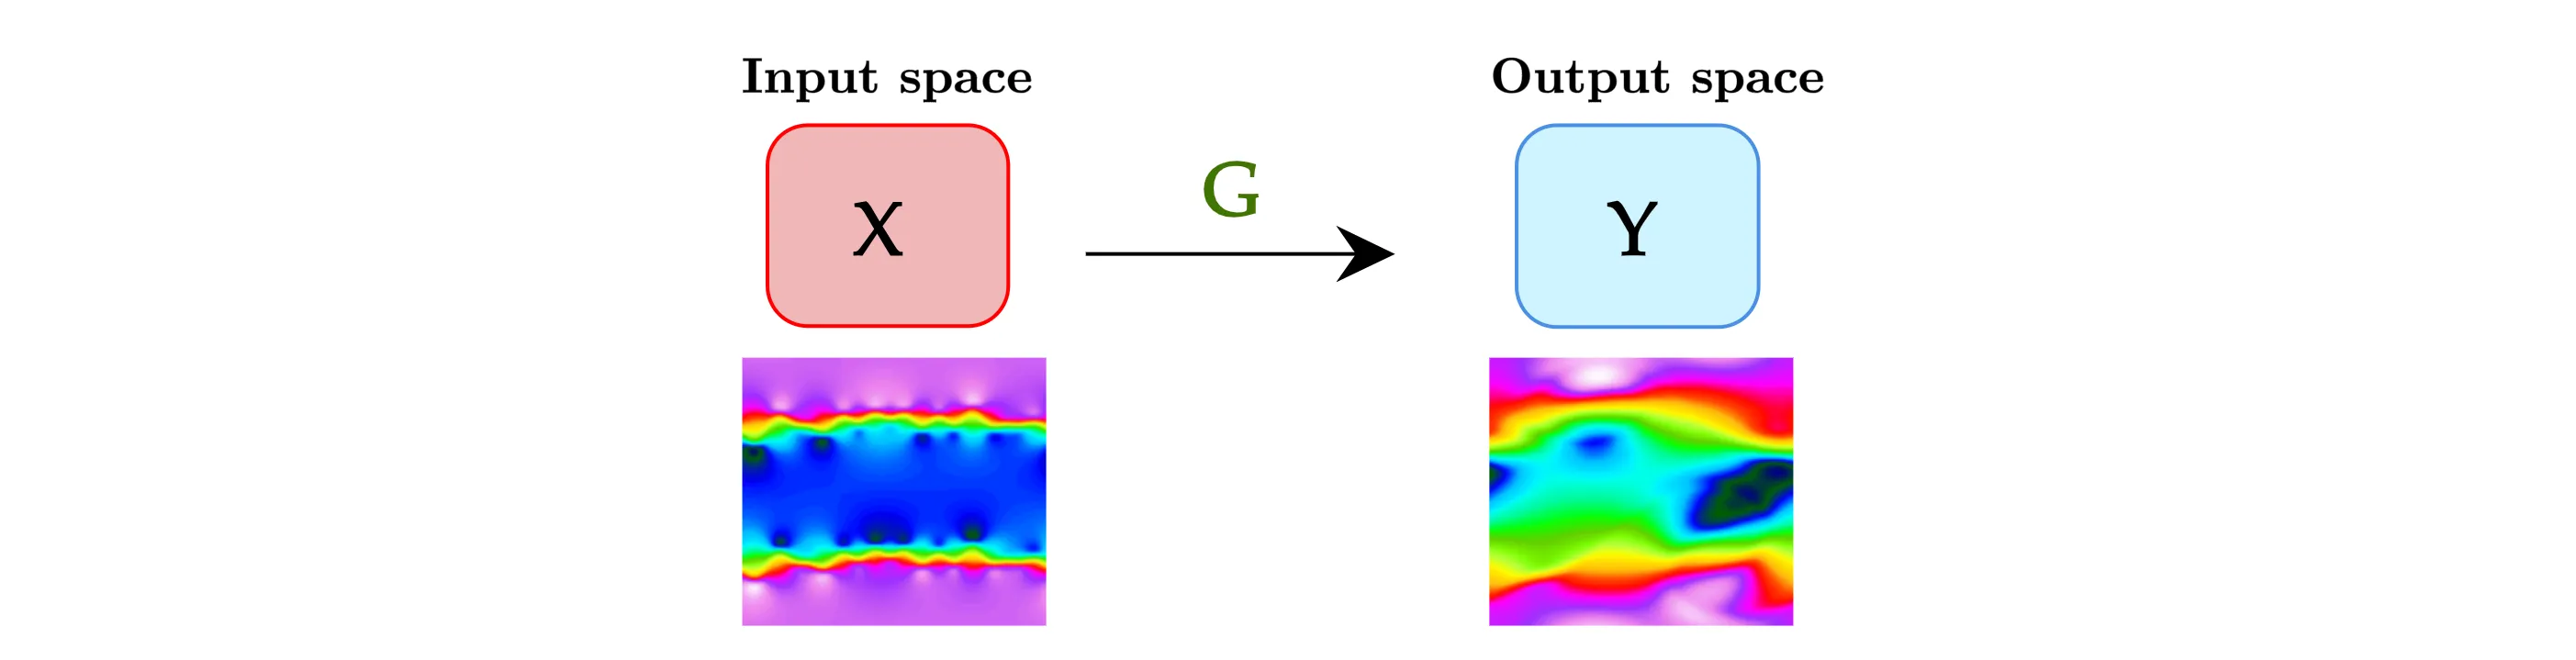

In **operator learning**, models are tasked with handling functions as inputs and outputs, which are stored on a computer in their **discrete representations** (e.g. images). They should have ability to process and generalize across various representations of the inputs, such as different mesh refinements.

Data-driven models that exhibit the mentioned properties are commonly known as ***Neural Operators***.

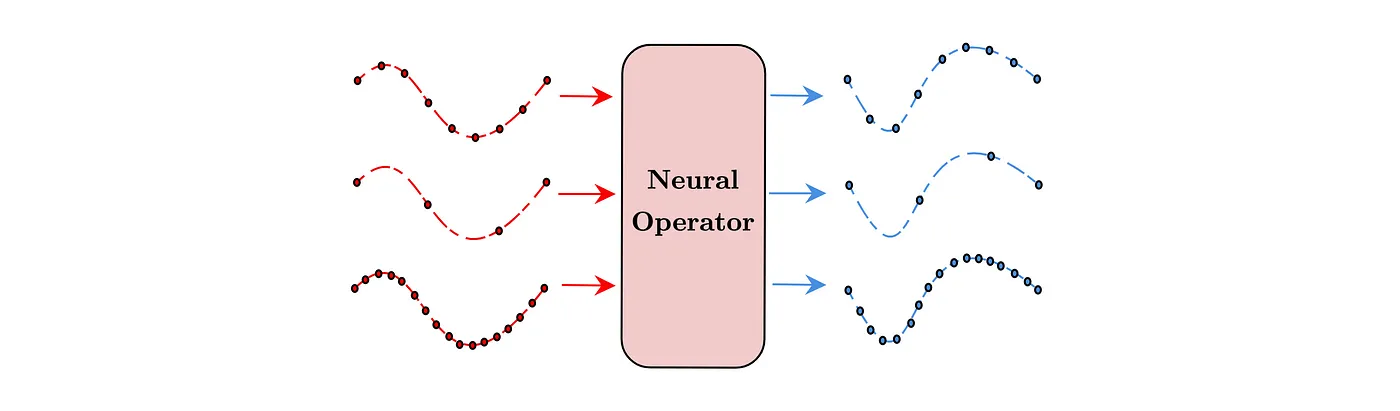



## Fourier Neural Operator (FNO)

- Introduced in the paper [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/abs/2010.08895).
- FNO is formulated as an **iterative architecture**
- FNO uses **convolutions** parametrized in the **frequency domain** (**global** operations)
- FNO uses **skip connections** to enchance the training

First layer is the **lifting layer** (in the channel dimension, increases the number of channels), while the last layer is the **projection layer** (reduces the number of channels.



You can read the blog at [FNO blog](https://zongyi-li.github.io/blog/2020/fourier-pde/).


![alt text](5375460525577726837.jpg)

The Fourier layer just consists of three steps:

1. Fourier transform (using FFT)

2. Linear transform on the lower Fourier modes

3. Inverse Fourier transform

In [2]:
pip install torch

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/204.1 MB 430.4 kB/s eta 0:07:53
   ---------------------------------------- 0.5/204.1 MB 430.4 kB/s eta 0:07:53
   ---------------------------------------- 0.8/204.1 MB 472.8 kB/s eta 0:07:10
   ---------------------------------------- 0.8/204.1 MB 472.8 kB/s eta 0:07:10
   ---------------------------------------- 1.0/204.1 MB 5

In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'torch'

In [2]:
def activation(name):
    if name in ['tanh', 'Tanh']:
        return nn.Tanh()
    elif name in ['relu', 'ReLU']:
        return nn.ReLU(inplace=True)
    elif name in ['lrelu', 'LReLU']:
        return nn.LeakyReLU(inplace=True)
    elif name in ['sigmoid', 'Sigmoid']:
        return nn.Sigmoid()
    elif name in ['softplus', 'Softplus']:
        return nn.Softplus(beta=4)
    elif name in ['celu', 'CeLU']:
        return nn.CELU()
    elif name in ['elu']:
        return nn.ELU()
    elif name in ['mish']:
        return nn.Mish()
    else:
        raise ValueError('Unknown activation function')


## Define Fourier layer in 1D (or Spectral Convolution)

In [3]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # x.shape == [batch_size, in_channels, number of grid points]

        # Compute Fourier coefficients
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1) // 2 + 1, device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes1] = self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights1)

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


## Fourier Neural Operator in 1D

In [4]:
class FNO1d(nn.Module):
    def __init__(self, modes, width):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .

        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        self.padding = 1  # pad the domain if input is non-periodic
        self.linear_p = nn.Linear(2, self.width)  # input channel is 2: (u0(x), x) --> GRID IS INCLUDED!

        self.spect1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.spect2 = SpectralConv1d(self.width, self.width, self.modes1)
        self.spect3 = SpectralConv1d(self.width, self.width, self.modes1)
        self.lin0 = nn.Conv1d(self.width, self.width, 1)
        self.lin1 = nn.Conv1d(self.width, self.width, 1)
        self.lin2 = nn.Conv1d(self.width, self.width, 1)

        self.linear_q = nn.Linear(self.width, 32)
        self.output_layer = nn.Linear(32, 1)

        self.activation = torch.nn.Tanh()

    def fourier_layer(self, x, spectral_layer, conv_layer):
        return self.activation(spectral_layer(x) + conv_layer(x))

    def linear_layer(self, x, linear_transformation):
        return self.activation(linear_transformation(x))

    def forward(self, x):
        # grid = self.get_grid(x.shape, x.device)
        # x = torch.cat((x, grid), dim=-1)
        x = self.linear_p(x)
        x = x.permute(0, 2, 1)

        # x = F.pad(x, [0, self.padding])  # pad the domain if input is non-periodic

        x = self.fourier_layer(x, self.spect1, self.lin0)
        x = self.fourier_layer(x, self.spect2, self.lin1)
        x = self.fourier_layer(x, self.spect3, self.lin2)

        # x = x[..., :-self.padding]  # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)

        x = self.linear_layer(x, self.linear_q)
        x = self.output_layer(x)
        return x


## Example

We will solve [Allen-Cahn](https://en.wikipedia.org/wiki/Allen%E2%80%93Cahn_equation) equation:

## $u_t = \Delta u - ϵ^2 u (u^2 - 1),\quad u\in\mathbb{R}×\mathbb{R_{>0}}$

Operator that we wish to learn is

## $\mathcal{G}: u(\cdot, t = 0) \mapsto  u(\cdot, t = 1)$

Note that the data is generated for you (see the files *AC_data_input.npy* and *AC_data_output.npy*).

In [5]:
torch.manual_seed(0)
np.random.seed(0)

In [6]:
x_data = torch.from_numpy(np.load("../datasets/allen_cahn/AC_data_input.npy")).type(torch.float32)
y_data = torch.from_numpy(np.load("../datasets/allen_cahn/AC_data_output.npy")).type(torch.float32)

tmp = torch.clone(x_data[:, :, 0])
x_data[:, :, 0] = x_data[:, :, 1]
x_data[:, :, 1] = tmp
print(x_data.shape, y_data.shape)

torch.Size([1000, 1001, 2]) torch.Size([1000, 1001])


In [7]:
# Dataset.
n_train = 100

x_train, y_train = x_data[:n_train, :], y_data[:n_train, :]
x_test, y_test = x_data[n_train:, :], y_data[n_train:, :]

# Dataloader.
training_set = DataLoader(TensorDataset(x_train, y_train),
                          batch_size=10,
                          shuffle=True)
testing_set = DataLoader(TensorDataset(x_test, y_test),
                         batch_size=10,
                         shuffle=False)

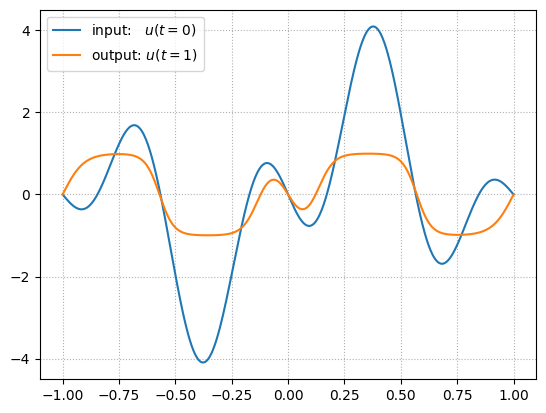

In [8]:
id_sample = 30

plt.plot(np.linspace(-1,1,x_data.shape[1]), x_data[id_sample, :, 0], label = "input:   $u(t = 0)$")
plt.plot(np.linspace(-1,1,x_data.shape[1]), y_data[id_sample, :], label = "output: $u(t = 1)$")
plt.grid(True, which="both", ls=":")
plt.legend()

In [9]:
learning_rate = 0.001
epochs = 10

In [10]:
modes = 16
width = 64
fno = FNO1d(modes, width)

## Training

In [11]:
optimizer = Adam(fno.parameters(), lr=learning_rate, weight_decay=1e-5)

l = torch.nn.MSELoss()
freq_print = 1
for epoch in range(epochs):
    train_mse = 0.0
    for step, (input_batch, output_batch) in enumerate(training_set):
        optimizer.zero_grad()
        output_pred_batch = fno(input_batch).squeeze(2)
        loss_f = l(output_pred_batch, output_batch)
        loss_f.backward()
        optimizer.step()
        train_mse += loss_f.item()
    train_mse /= len(training_set)

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            output_pred_batch = fno(input_batch).squeeze(2)
            loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100
            test_relative_l2 += loss_f.item()
        test_relative_l2 /= len(testing_set)

    if epoch % freq_print == 0: print("######### Epoch:", epoch, " ######### Train Loss:", train_mse, " ######### Relative L2 Test Norm:", test_relative_l2)

/home/mpenkin/venv_sber-spatial/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


######### Epoch: 0  ######### Train Loss: 0.30418637208640575  ######### Relative L2 Test Norm: 38.978488773769804
######### Epoch: 1  ######### Train Loss: 0.06348589863628148  ######### Relative L2 Test Norm: 24.926398626963298
######### Epoch: 2  ######### Train Loss: 0.036170807760208847  ######### Relative L2 Test Norm: 16.515777142842612
######### Epoch: 3  ######### Train Loss: 0.016960198897868393  ######### Relative L2 Test Norm: 13.224724091423882
######### Epoch: 4  ######### Train Loss: 0.013662096252664924  ######### Relative L2 Test Norm: 11.714263031217786
######### Epoch: 5  ######### Train Loss: 0.008291577617637814  ######### Relative L2 Test Norm: 10.766488541497125
######### Epoch: 6  ######### Train Loss: 0.007858115318231284  ######### Relative L2 Test Norm: 10.443439356486003
######### Epoch: 7  ######### Train Loss: 0.0076524641830474135  ######### Relative L2 Test Norm: 9.872486559549968
######### Epoch: 8  ######### Train Loss: 0.005044723185710609  ######### 

## Plot

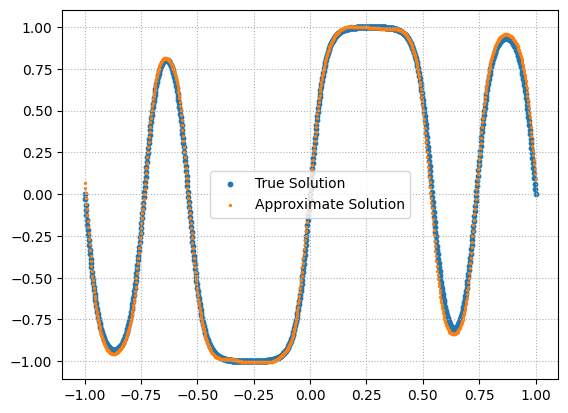

In [12]:
id_sample = 199
x_sample = x_test[id_sample].unsqueeze(0)
y_sample = y_test[id_sample, :].unsqueeze(0)
y_pred_sample = fno(x_sample)

plt.figure()
plt.grid(True, which="both", ls=":")
plt.scatter(x_sample[0, :, 1].detach(), y_sample[0].detach(), label="True Solution", s=10)
plt.scatter(x_sample[0, :, 1].detach(), y_pred_sample[0].detach(), label="Approximate Solution", s=2)

plt.legend()

# Homework

In [13]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul2d(self, input, weights):
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(self, x):
        raise NotImplementedError